In [50]:
from pymatgen.ext.matproj import MPRester
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc

with MPRester("oq0PgNNYTST8xQ2xXfJpkLwNQFB5QgBT") as mpr:
    structure = mpr.get_structure_by_material_id("mp-1018096")
    ph_dos = mpr.get_phonon_dos_by_material_id("mp-1018096")
    N_at = len(structure)

Text(0.5, 1.0, 'Phonon Density of States for mp-1018096')

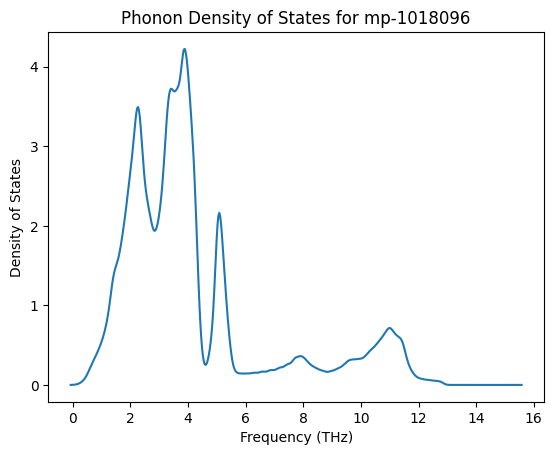

In [51]:
frequencies = ph_dos.frequencies
dos = ph_dos.densities
plt.plot(frequencies, dos)
plt.xlabel("Frequency (THz)")
plt.ylabel("Density of States")
plt.title("Phonon Density of States for mp-1018096")

In [52]:
def calculate_einstein_cv(te, temperature):
    return 3 * N_at * sc.constants.R * (te / temperature)**2 * np.exp(te / temperature) / (np.exp(te / temperature) - 1)**2

def calculate_debye_cv(td, temperature):
    integral, _ = sc.integrate.quad(lambda t: (t**4 * np.exp(t)) / (np.exp(t) - 1)**2, 0, td/temperature)
    return 9 * N_at * sc.constants.R * (temperature / td)**3 * integral

T = np.array(range(5, 500))
t_einstein = sc.optimize.least_squares(lambda te: np.ravel([calculate_einstein_cv(te, T[i]) - ph_dos.cv(T[i]) for i in range(len(T))]), x0=100)
t_debye = sc.optimize.least_squares(lambda td: np.ravel([calculate_debye_cv(td, T[i]) - ph_dos.cv(T[i]) for i in range(len(T))]), x0=100)
print(f"Einstein temperature: {t_einstein.x[0]} K")
print(f"Debye temperature: {t_debye.x[0]} K")

Einstein temperature: 182.24637660018487 K
Debye temperature: 247.61953332280453 K


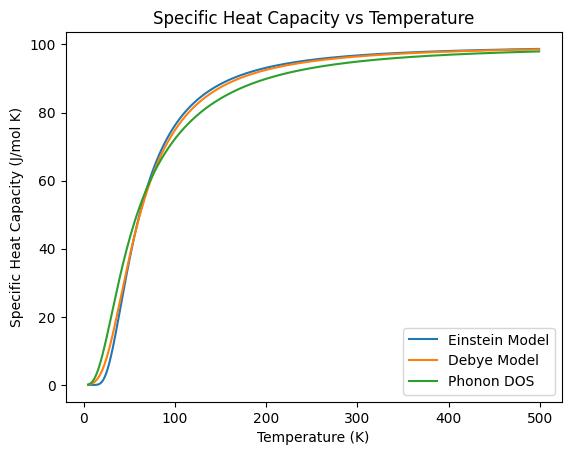

In [53]:
# Plotting the specific heat capacities
cv_einstein = [calculate_einstein_cv(t_einstein.x[0], T[i]) for i in range(len(T))]
cv_debye = [calculate_debye_cv(t_debye.x[0], T[i]) for i in range(len(T))]
cv_ph_dos = [ph_dos.cv(T[i]) for i in range(len(T))]
plt.figure()
plt.plot(T, cv_einstein, label="Einstein Model")
plt.plot(T, cv_debye, label="Debye Model")
plt.plot(T, cv_ph_dos, label="Phonon DOS")
plt.xlabel("Temperature (K)")
plt.ylabel("Specific Heat Capacity (J/mol K)")
plt.title("Specific Heat Capacity vs Temperature")
plt.legend()
plt.show()

Frequencies from DOS: -0.07237652312794202 THz to 15.576789784475361 THz


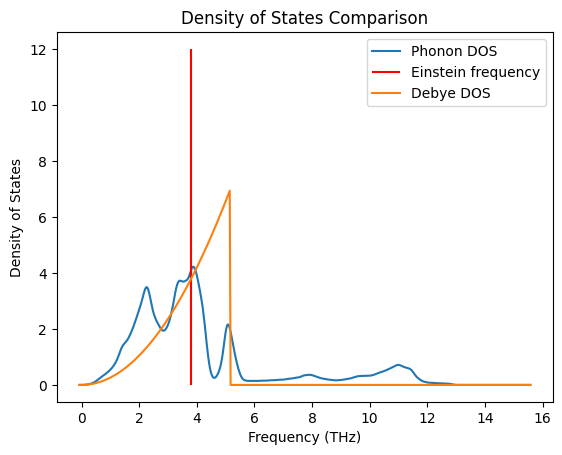

Einstein frequency: 3.797398335824571e-12 THz
Debye frequency: 5.159553903343398e-12 THz
Frequencies from DOS: -0.07237652312794202 THz to 15.576789784475361 THz


In [94]:
f_d = t_debye.x[0] * sc.constants.k / sc.constants.h * 1e-12  # Convert to THz
f_e = t_einstein.x[0] * sc.constants.k / sc.constants.h * 1e-12  # Convert to THz

def debye_dos(frequency):
    if(frequency <= f_d):
        return 9 * N_at * (frequency)**2 / ((f_d)**3)
    else:
        return 0

print(f"Frequencies from DOS: {frequencies[0]} THz to {frequencies[-1]} THz")
d_dos = [debye_dos(f) for f in frequencies]  # Convert THz to Hz

plt.figure()
plt.plot(frequencies, dos, label="Phonon DOS")
plt.vlines(f_e, 0, 3*N_at, label="Einstein frequency", colors='r')
plt.plot(frequencies, d_dos, label="Debye DOS")
plt.xlabel("Frequency (THz)")
plt.ylabel("Density of States")
plt.title("Density of States Comparison")
plt.legend()
plt.show()

print(f"Einstein frequency: {f_e * 1e-12} THz")
print(f"Debye frequency: {f_d * 1e-12} THz")
print(f"Frequencies from DOS: {frequencies[0]} THz to {frequencies[-1]} THz")